Wine Dataset Analysis
    EDA

In [61]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import seaborn as sns                       #visualisation
%matplotlib inline
sns.set(color_codes=True)

In [62]:
#Load Dataset
data = pd.read_csv("/WineDataset.csv")

display(data.head(5))
display(data.tail(5))


,Title,Description,Price,Capacity,Grape,Secondary Grape Varieties,Closure,Country,Unit,Characteristics,Per bottle / case / each,Type,ABV,Region,Style,Vintage,Appellation
0,"The Guv'nor, Spain",We asked some of our most prized winemakers wo...,£9.99 per bottle,75CL,Tempranillo,NaN,Natural Cork,Spain,10.5,"Vanilla, Blackberry, Blackcurrant",per bottle,Red,ABV 14.00%,NaN,Rich & Juicy,NV,NaN
1,Bread & Butter 'Winemaker's Selection' Chardon...,This really does what it says on the tin. It’s...,£15.99 per bottle,75CL,Chardonnay,NaN,Natural Cork,USA,10.1,"Vanilla, Almond, Coconut, Green Apple, Peach, ...",per bottle,White,ABV 13.50%,California,Rich & Toasty,2021,Napa Valley
2,"Oyster Bay Sauvignon Blanc 2022, Marlborough",Oyster Bay has been an award-winning gold-stan...,£12.49 per bottle,75CL,Sauvignon Blanc,NaN,Screwcap,New Zealand,9.8,"Tropical Fruit, Gooseberry, Grapefruit, Grass,...",per bottle,White,ABV 13.00%,Marlborough,Crisp & Zesty,2022,NaN
3,Louis Latour Mâcon-Lugny 2021/22,We’ve sold this wine for thirty years – and fo...,£17.99 per bottle,75CL,Chardonnay,NaN,Natural Cork,France,10.1,"Peach, Apricot, Floral, Lemon",per bottle,White,ABV 13.50%,Burgundy,Ripe & Rounded,2022,Macon
4,Bread & Butter 'Winemaker's Selection' Pinot N...,Bread & Butter is that thing that you can coun...,£15.99 per bottle,75CL,Pinot Noir,NaN,Natural Cork,USA,10.1,"Smoke, Black Cherry, Cedar, Raspberry, Red Fruit",per bottle,Red,ABV 13.50%,California,Smooth & Mellow,2021,Napa Valley


,Title,Description,Price,Capacity,Grape,Secondary Grape Varieties,Closure,Country,Unit,Characteristics,Per bottle / case / each,Type,ABV,Region,Style,Vintage,Appellation
1285,"Vouvray Sec 'Expresion de Silex' 2020/21, Loire",Although Denis Meunier is only in his late 20s...,£11.99 per bottle,75CL,Chenin Blanc,NaN,Natural Cork,France,9.4,"Quince, Green Apple, Lemon, Pear",per bottle,White,ABV 12.50%,Loire,Aromatic & Floral,2021,Vouvray
1286,"Waimea Estates Pinot Noir Rosé 2021, Nelson",Waimea’s vineyards are less than 1km from the ...,£13.99 per bottle,75CL,Pinot Noir,NaN,Screwcap,New Zealand,9.8,"Floral, Raspberry, Red Cherry, Strawberry",per bottle,Rosé,ABV 13.00%,Nelson,Delicate & Dry,2021,NaN
1287,Wakefield 'Visionary' Cabernet Sauvignon 2010,Made from the very best fruit nourished by 40-...,£85.00 per bottle,75CL,Cabernet Sauvignon,NaN,Screwcap,Australia,10.1,"Vanilla, Blackberry, Blackcurrant, Cedar, Euca...",per bottle,Red,ABV 13.50%,South Australia,Savoury & Full Bodied,2010,Clare Valley
1288,Yalumba 'The Menzies' Cabernet Sauvignon 2015/...,"In 1961, Sir Robert Menzies said that Yalumba'...",£37.99 per bottle,75CL,Cabernet Sauvignon,NaN,Natural Cork,Australia,10.9,"Black Plum, Blackcurrant, Vanilla",per bottle,Red,ABV 14.50%,South Australia,Savoury & Full Bodied,2016,Coonawarra
1289,"Yalumba 'Virgilius' Viognier 2017, Eden Valley",Yalumba's Virgilius is often regarded as Austr...,£34.99 per bottle,75CL,Viognier,NaN,Screwcap,Australia,10.1,"Peach, Apricot, Floral, Honeysuckle",per bottle,White,ABV 13.50%,NaN,Aromatic & Floral,2017,Eden Valley


In [63]:
#check data types
data.dtypes

Title                            str
Description                      str
Price                            str
Capacity                         str
Grape                            str
Secondary Grape Varieties        str
Closure                          str
Country                          str
Unit                         float64
Characteristics                  str
Per bottle / case / each         str
Type                             str
ABV                              str
Region                           str
Style                            str
Vintage                          str
Appellation                      str
dtype: object

In [64]:

data.info()
data.shape
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1290 entries, 0 to 1289
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Title                      1290 non-null   str    
 1   Description                1286 non-null   str    
 2   Price                      1290 non-null   str    
 3   Capacity                   1290 non-null   str    
 4   Grape                      1275 non-null   str    
 5   Secondary Grape Varieties  488 non-null    str    
 6   Closure                    1279 non-null   str    
 7   Country                    1284 non-null   str    
 8   Unit                       1281 non-null   float64
 9   Characteristics            1253 non-null   str    
 10  Per bottle / case / each   1290 non-null   str    
 11  Type                       1285 non-null   str    
 12  ABV                        1281 non-null   str    
 13  Region                     1124 non-null   str    
 14  Sty

,Unit
count,1281.000000
mean,10.177674
std,2.318850
min,0.000000
25%,9.400000
50%,10.100000
75%,10.500000
max,39.000000


In [65]:
#look for duplicates
data.duplicated().sum()

np.int64(0)

In [66]:
#look for null values
data.isnull().sum()


Title                          0
Description                    4
Price                          0
Capacity                       0
Grape                         15
Secondary Grape Varieties    802
Closure                       11
Country                        6
Unit                           9
Characteristics               37
Per bottle / case / each       0
Type                           5
ABV                            9
Region                       166
Style                         78
Vintage                        7
Appellation                  646
dtype: int64

<Axes: >

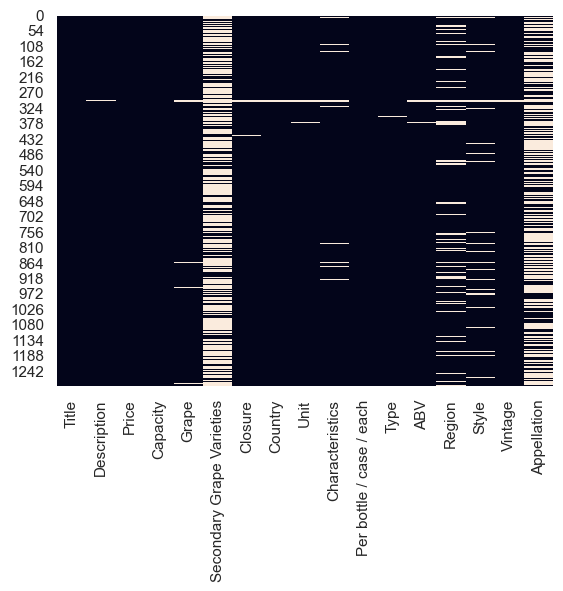

In [67]:
#explore missing values
sns.heatmap(data.isnull(), cbar = False)

<Axes: >

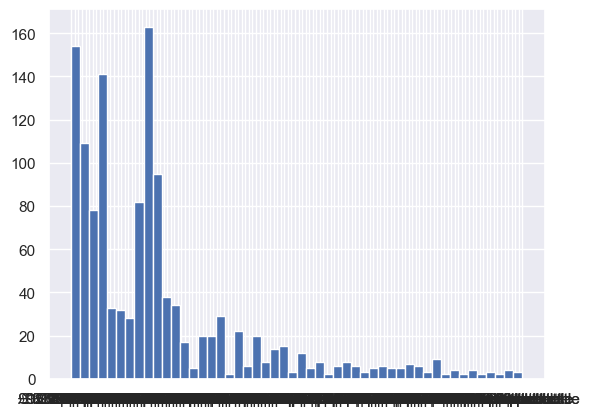

In [68]:
#explore univariate distributions - see outliers
data['Price'].hist(bins=50)

<Axes: >

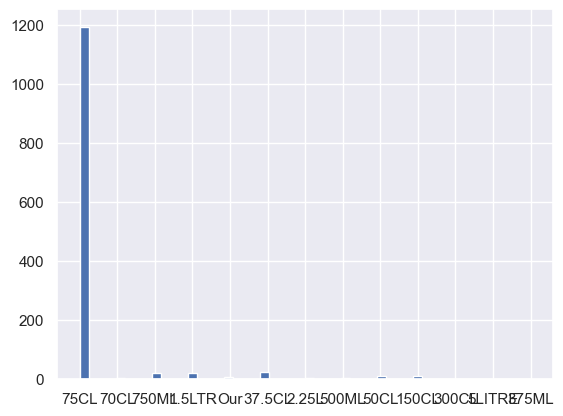

In [69]:
data['Capacity'].hist(bins=50)

<Axes: >

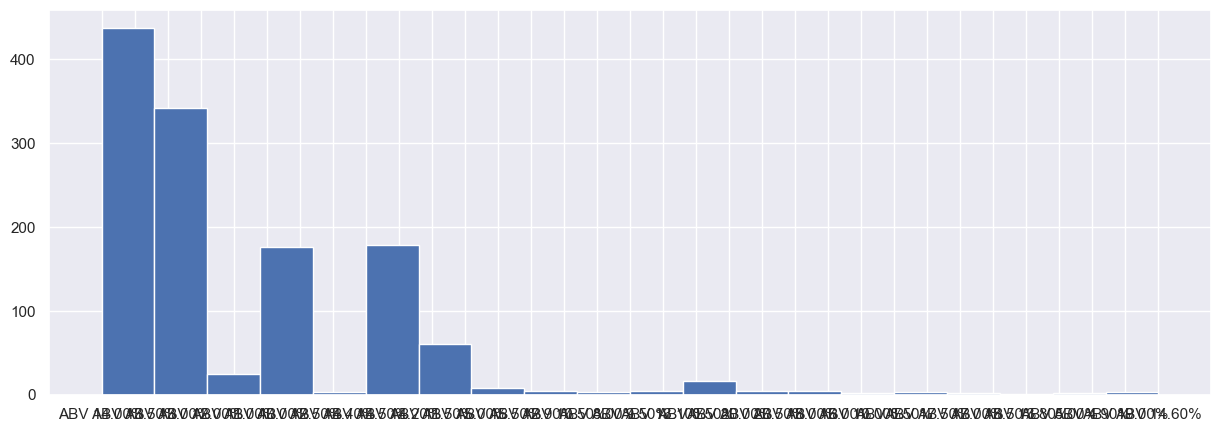

In [70]:
from matplotlib import pyplot as plt

plt.figure(figsize=(15,5))
data['ABV'].hist(bins=20)


In [92]:
#look for strage values in columns

display(
    data['Grape']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Secondary Grape Varieties']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Closure']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Country']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Vintage']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Characteristics']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Vintage']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Per bottle / case / each']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Type']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Region']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Style']
    .value_counts()
    .reset_index(name='Count')
)

display(
    data['Appellation']
    .value_counts()
    .reset_index(name='Count')
)
#closure, country

,Grape,Count
0,Chardonnay,237
1,Pinot Noir,116
2,Sauvignon Blanc,102
3,Cabernet Sauvignon,87
4,Grenache,82
...,...,...
109,Tibouren,1
110,Grolleau,1
111,Inzolia,1
112,Falanghina,1


,Secondary Grape Varieties,Count
0,None,802
1,"Pinot Noir, Pinot Meunier",36
2,Pinot Noir,35
3,Merlot,25
4,Syrah,23
...,...,...
194,"Touriga Nacional, Tinta Amarela, Tinta Roriz, ...",1
195,Roussanne,1
196,Ugni Blanc,1
197,"Syrah, Garnacha",1


,Closure,Count
0,Natural Cork,834
1,Screwcap,414
2,Synthetic Cork,24
3,Unknown,11
4,Vinolok,7


,Country,Count
0,France,502
1,Italy,147
2,Spain,113
3,Australia,96
4,New Zealand,91
5,South Africa,77
6,USA,51
7,Chile,46
8,Portugal,44
9,Argentina,40


,Vintage,Count
0,2022.0,318
1,2021.0,261
2,2020.0,194
3,2019.0,101
4,2018.0,69
5,2017.0,45
6,2016.0,22
7,2015.0,19
8,2014.0,17
9,2023.0,12


...

,Per bottle / case / each,Count
0,per bottle,1279
1,per case,6
2,each,5


,Type,Count
0,White,584
1,Red,569
2,Rosé,124
3,Unknown,5
4,Tawny,4
5,Orange,2
6,Brown,1
7,Mixed,1


,Region,Count
0,Unknown,166
1,Burgundy,101
2,Bordeaux,67
3,Marlborough,65
4,Loire,59
...,...,...
90,Oregon,1
91,Coastal,1
92,Elgin,1
93,Bulgaria,1


,Style,Count
0,Savoury & Full Bodied,154
1,Rich & Toasty,141
2,Bold & Spicy,113
3,Light & Elegant,104
4,Crisp & Zesty,98
5,Fresh & Elegant,95
6,Ripe & Rounded,91
7,Crisp & Fruity,83
8,Unknown,78
9,Rich & Juicy,65


,Appellation,Count
0,Rioja,45
1,Barossa Valley,23
2,Chablis,15
3,Côtes De Provence,14
4,Sancerre,14
...,...,...
174,Morey-Saint-Denis,1
175,Rutherglen,1
176,Rheingau,1
177,Hunter Valley,1


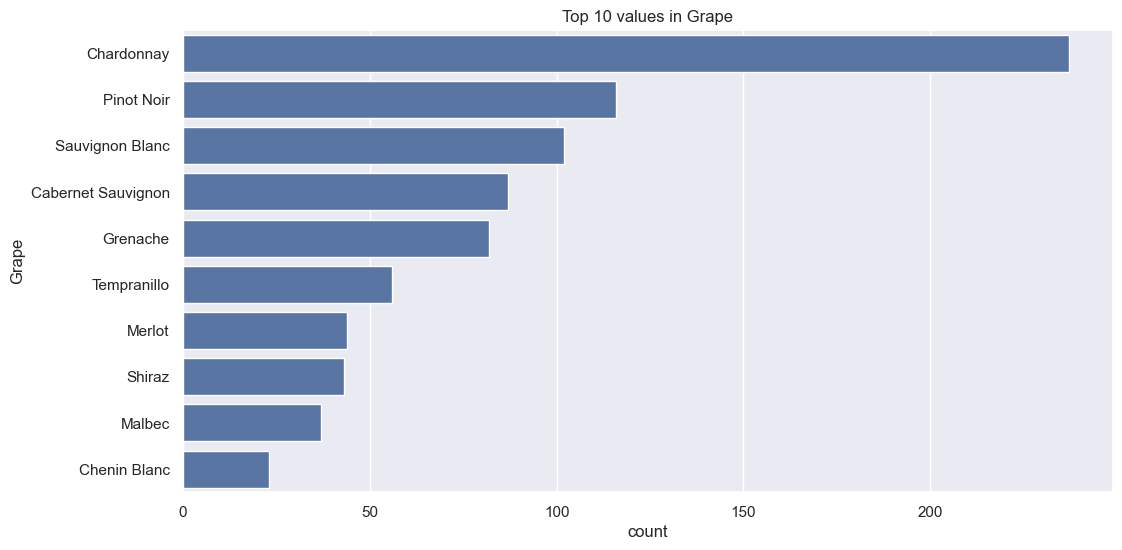

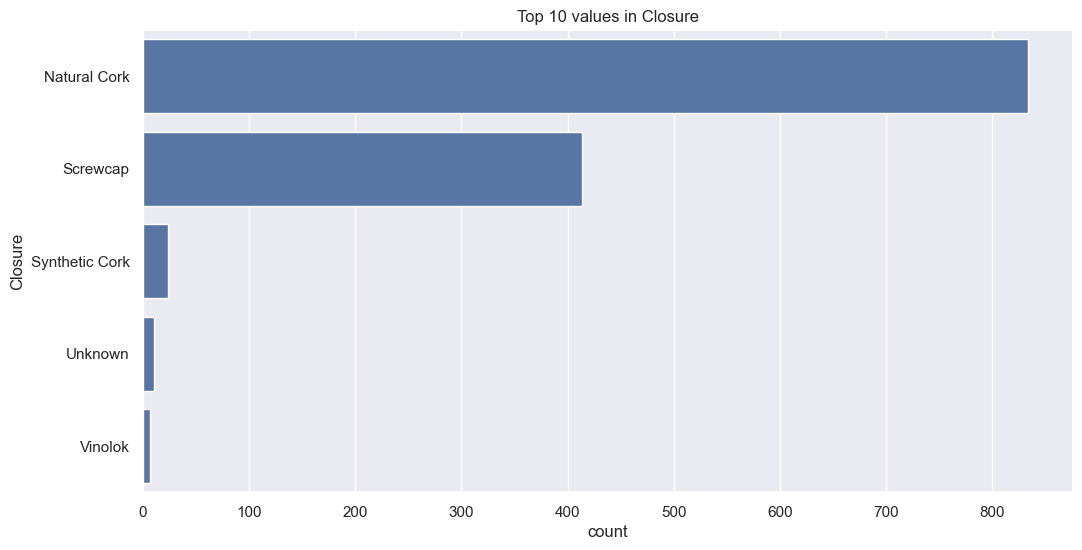

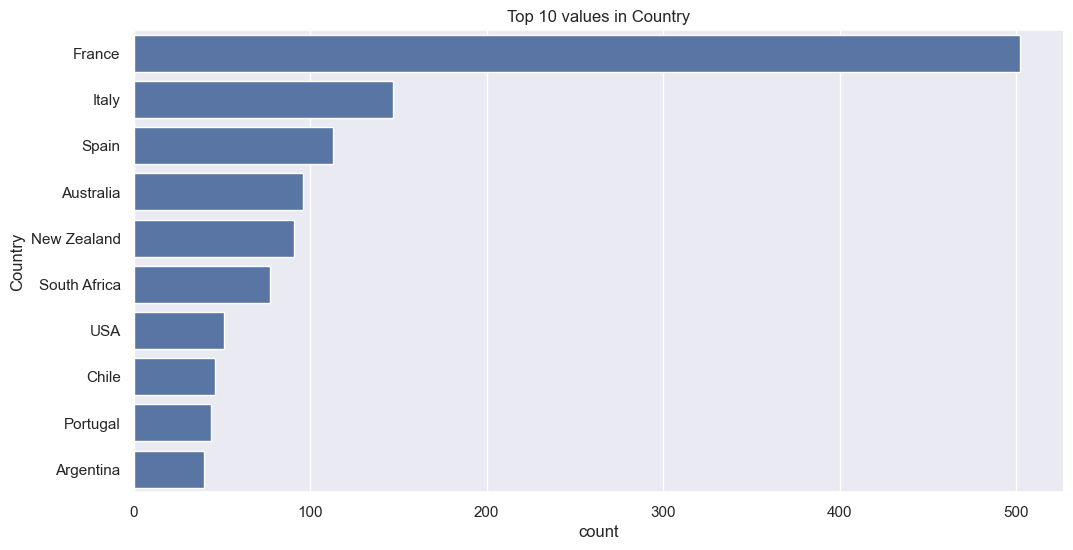

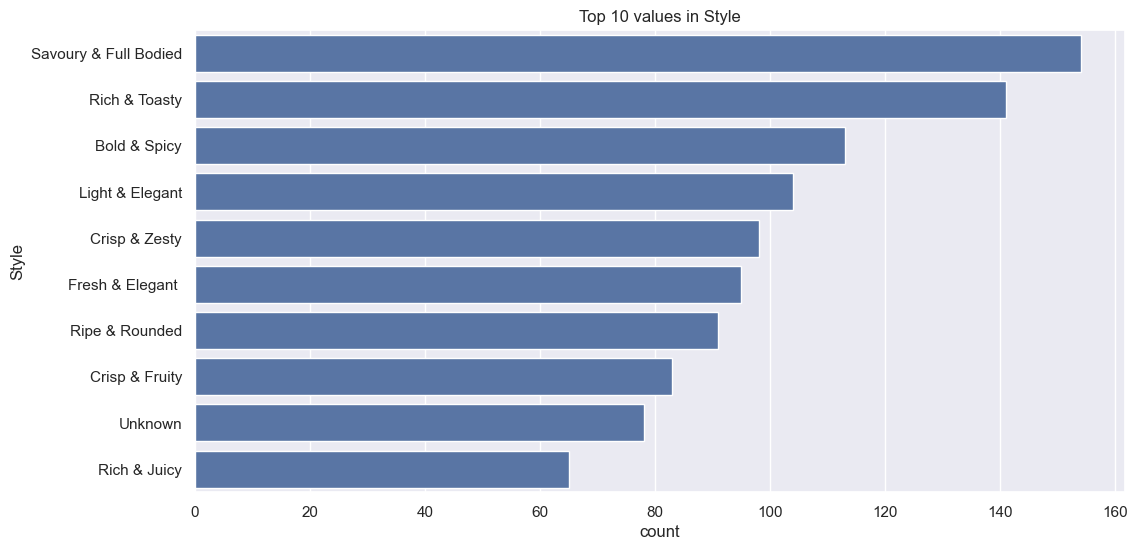

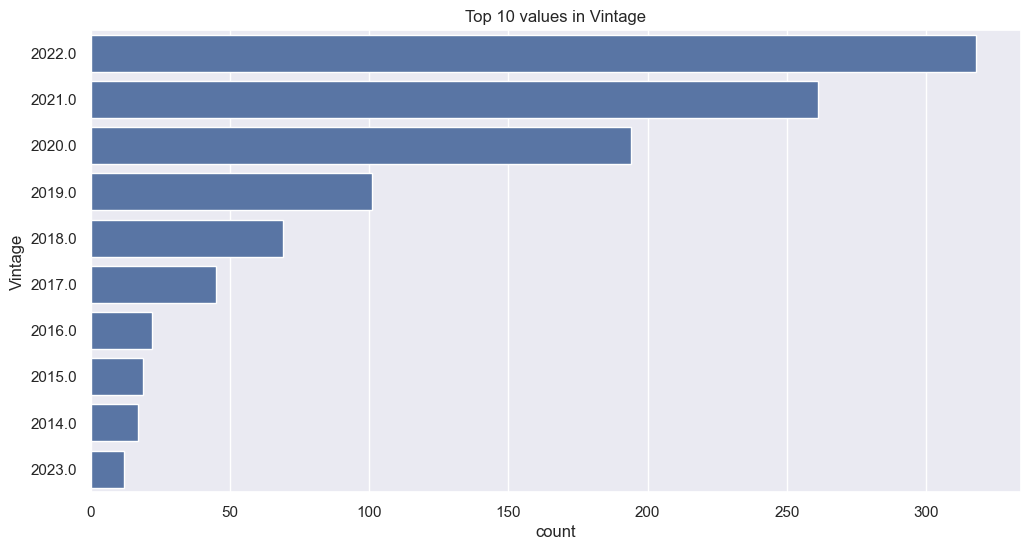

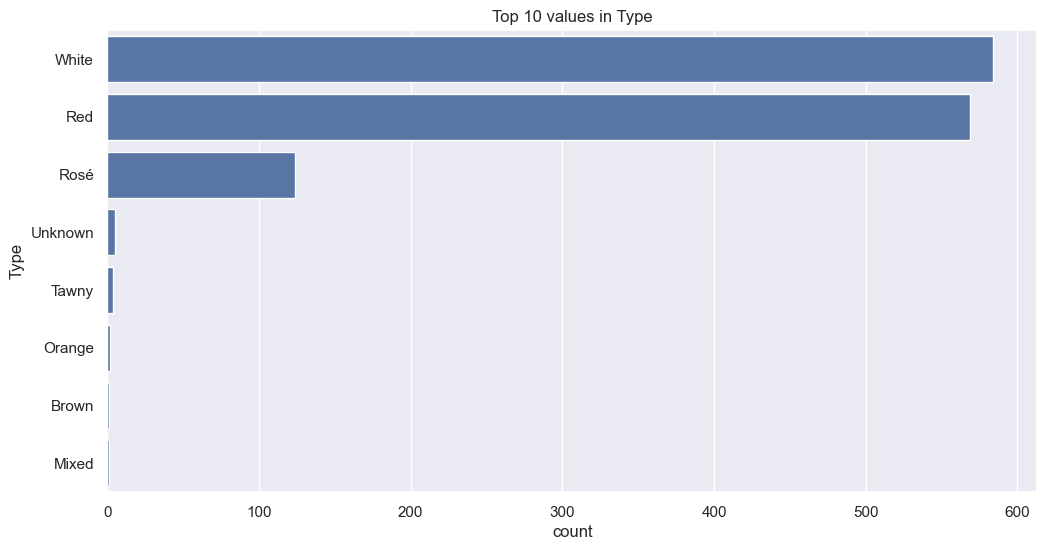

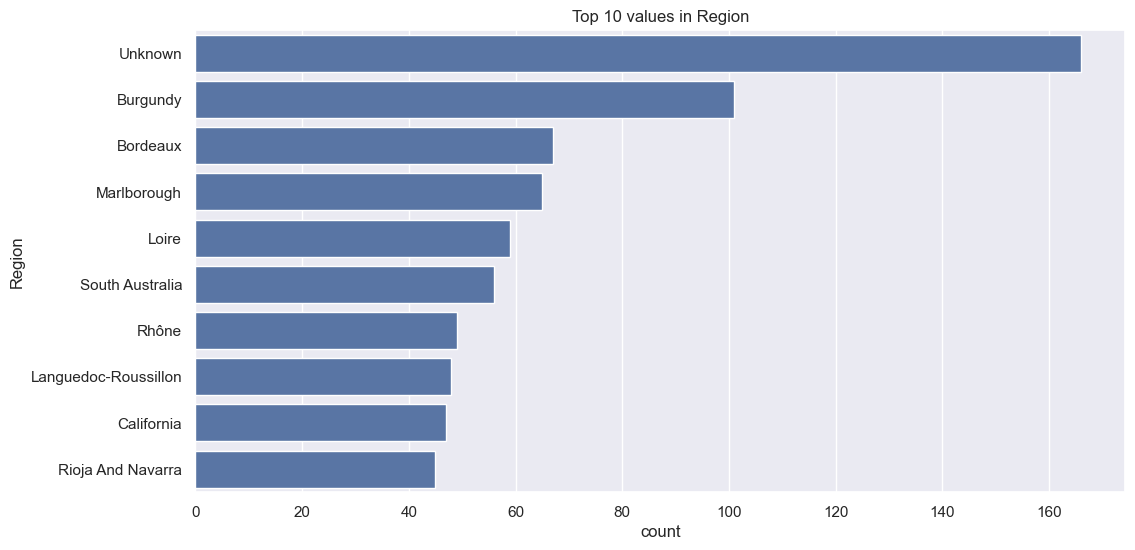

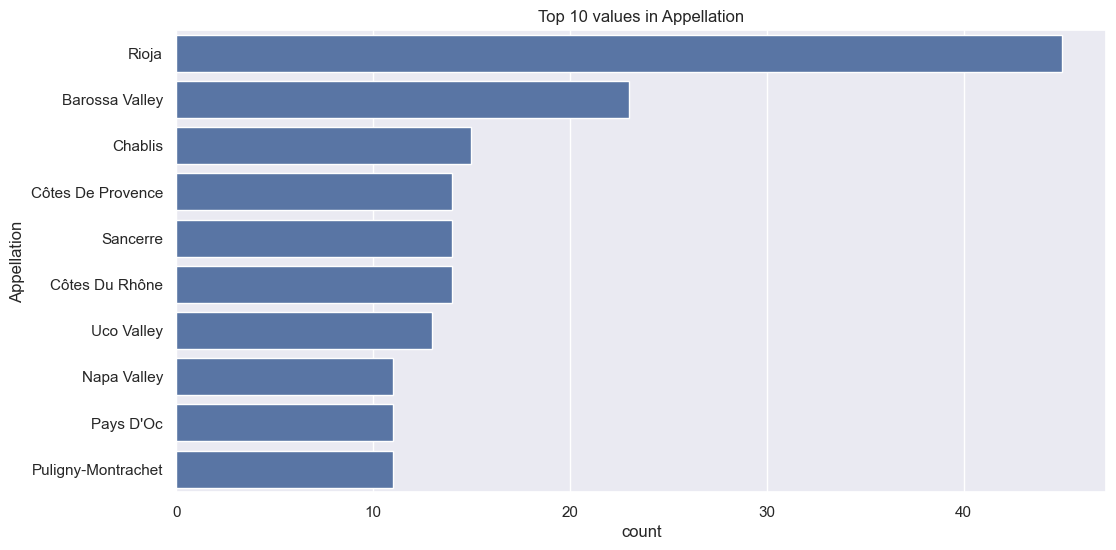

In [93]:
#explore value frequency in categorical features
def plot_category(col, top_n=10):
    plt.figure(figsize=(12,6))
    sns.countplot(
        y=col,
        data=data,
        order=data[col].value_counts().index[:top_n]
    )
    plt.title(f"Top {top_n} values in {col}")
    plt.show()

plot_category('Grape')
plot_category('Closure')
plot_category('Country')
plot_category('Style')
plot_category('Vintage')
plot_category('Type')
plot_category('Region')
plot_category('Appellation')


Preprocessing


change column type from string to numeric for: Price, Capacity, ABV


In [79]:
data['Price'] = (data['Price'].astype(str).str.replace(r'[^0-9.]', '', regex = True))
data['Price'] = pd.to_numeric(data['Price'], errors='coerce')

data['Capacity'] = (data['Capacity'].astype(str).str.replace(r'[^0-9.]', '', regex = True))
data['Capacity'] = pd.to_numeric(data['Capacity'], errors='coerce')

data['ABV'] = (data['ABV'].astype(str).str.replace(r'[^0-9.]', '', regex = True))
data['ABV'] = pd.to_numeric(data['ABV'], errors='coerce')

#data['Vintage'] = data['Vintage'].astype(int)  #leave it for now -> it also has NV (non vintage) values

#check data types
display(data.head(5))
display(data.tail(5))

,Title,Description,Price,Capacity,Grape,Secondary Grape Varieties,Closure,Country,Unit,Characteristics,Per bottle / case / each,Type,ABV,Region,Style,Vintage,Appellation
0,"The Guv'nor, Spain",We asked some of our most prized winemakers wo...,9.99,75.0,Tempranillo,NaN,Natural Cork,Spain,10.5,"Vanilla, Blackberry, Blackcurrant",per bottle,Red,14.0,NaN,Rich & Juicy,NV,NaN
1,Bread & Butter 'Winemaker's Selection' Chardon...,This really does what it says on the tin. It’s...,15.99,75.0,Chardonnay,NaN,Natural Cork,USA,10.1,"Vanilla, Almond, Coconut, Green Apple, Peach, ...",per bottle,White,13.5,California,Rich & Toasty,2021,Napa Valley
2,"Oyster Bay Sauvignon Blanc 2022, Marlborough",Oyster Bay has been an award-winning gold-stan...,12.49,75.0,Sauvignon Blanc,NaN,Screwcap,New Zealand,9.8,"Tropical Fruit, Gooseberry, Grapefruit, Grass,...",per bottle,White,13.0,Marlborough,Crisp & Zesty,2022,NaN
3,Louis Latour Mâcon-Lugny 2021/22,We’ve sold this wine for thirty years – and fo...,17.99,75.0,Chardonnay,NaN,Natural Cork,France,10.1,"Peach, Apricot, Floral, Lemon",per bottle,White,13.5,Burgundy,Ripe & Rounded,2022,Macon
4,Bread & Butter 'Winemaker's Selection' Pinot N...,Bread & Butter is that thing that you can coun...,15.99,75.0,Pinot Noir,NaN,Natural Cork,USA,10.1,"Smoke, Black Cherry, Cedar, Raspberry, Red Fruit",per bottle,Red,13.5,California,Smooth & Mellow,2021,Napa Valley


,Title,Description,Price,Capacity,Grape,Secondary Grape Varieties,Closure,Country,Unit,Characteristics,Per bottle / case / each,Type,ABV,Region,Style,Vintage,Appellation
1285,"Vouvray Sec 'Expresion de Silex' 2020/21, Loire",Although Denis Meunier is only in his late 20s...,11.99,75.0,Chenin Blanc,NaN,Natural Cork,France,9.4,"Quince, Green Apple, Lemon, Pear",per bottle,White,12.5,Loire,Aromatic & Floral,2021,Vouvray
1286,"Waimea Estates Pinot Noir Rosé 2021, Nelson",Waimea’s vineyards are less than 1km from the ...,13.99,75.0,Pinot Noir,NaN,Screwcap,New Zealand,9.8,"Floral, Raspberry, Red Cherry, Strawberry",per bottle,Rosé,13.0,Nelson,Delicate & Dry,2021,NaN
1287,Wakefield 'Visionary' Cabernet Sauvignon 2010,Made from the very best fruit nourished by 40-...,85.00,75.0,Cabernet Sauvignon,NaN,Screwcap,Australia,10.1,"Vanilla, Blackberry, Blackcurrant, Cedar, Euca...",per bottle,Red,13.5,South Australia,Savoury & Full Bodied,2010,Clare Valley
1288,Yalumba 'The Menzies' Cabernet Sauvignon 2015/...,"In 1961, Sir Robert Menzies said that Yalumba'...",37.99,75.0,Cabernet Sauvignon,NaN,Natural Cork,Australia,10.9,"Black Plum, Blackcurrant, Vanilla",per bottle,Red,14.5,South Australia,Savoury & Full Bodied,2016,Coonawarra
1289,"Yalumba 'Virgilius' Viognier 2017, Eden Valley",Yalumba's Virgilius is often regarded as Austr...,34.99,75.0,Viognier,NaN,Screwcap,Australia,10.1,"Peach, Apricot, Floral, Honeysuckle",per bottle,White,13.5,NaN,Aromatic & Floral,2017,Eden Valley


In [80]:

data.dtypes

Title                            str
Description                      str
Price                        float64
Capacity                     float64
Grape                            str
Secondary Grape Varieties        str
Closure                          str
Country                          str
Unit                         float64
Characteristics                  str
Per bottle / case / each         str
Type                             str
ABV                          float64
Region                           str
Style                            str
Vintage                          str
Appellation                      str
dtype: object

handle missing values

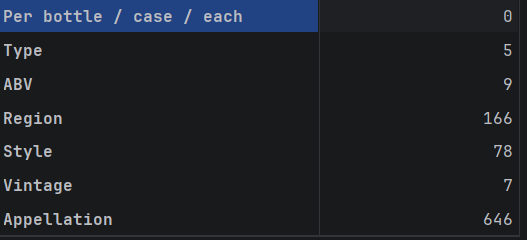

In [81]:
data.isnull().sum()

Title                          0
Description                    4
Price                          0
Capacity                       6
Grape                         15
Secondary Grape Varieties    802
Closure                       11
Country                        6
Unit                           9
Characteristics               37
Per bottle / case / each       0
Type                           5
ABV                            9
Region                       166
Style                         78
Vintage                        7
Appellation                  646
dtype: int64

In [82]:
data['Grape'] = data['Grape'].fillna('Unknown')
data['Closure'] = data['Closure'].fillna('Unknown')
data['Country'] = data['Country'].fillna('Unknown')
data['Region'] = data['Region'].fillna('Unknown')
data['Style'] = data['Style'].fillna('Unknown')
data['Type'] = data['Type'].fillna('Unknown')
data['Characteristics'] = data['Characteristics'].fillna('Unknown')
data['Description'] = data['Description'].fillna('No description available')

#there are many missing values => the presence of appellation in a wine might influence the price
data['Has_Appellation'] = data['Appellation'].notna().astype(int)

#Secondary Grape Varieties might be hard to correlate with target 'Price'
data['Has_Secondary_Grape'] = data['Secondary Grape Varieties'].notna().astype(int)
data['Secondary Grape Varieties'] = data['Secondary Grape Varieties'].fillna('None')

In [83]:
#for numerical columns: (from eda) the distribution of the values is not uniform -> median imputation
from sklearn.impute import SimpleImputer
median_imputer = SimpleImputer(strategy='median')
data['Capacity'] = median_imputer.fit_transform(data[['Capacity']]).ravel()
data['Unit'] = median_imputer.fit_transform(data[['Unit']]).ravel()
data['ABV'] = median_imputer.fit_transform(data[['ABV']]).ravel()

data['Is_NV'] = data['Vintage'].eq('NV').astype(int)
data['Vintage'] = pd.to_numeric(data['Vintage'], errors='coerce')


In [84]:
data.isnull().sum()

Title                          0
Description                    0
Price                          0
Capacity                       0
Grape                          0
Secondary Grape Varieties      0
Closure                        0
Country                        0
Unit                           0
Characteristics                0
Per bottle / case / each       0
Type                           0
ABV                            0
Region                         0
Style                          0
Vintage                      190
Appellation                  646
Has_Appellation                0
Has_Secondary_Grape            0
Is_NV                          0
dtype: int64

<Axes: >

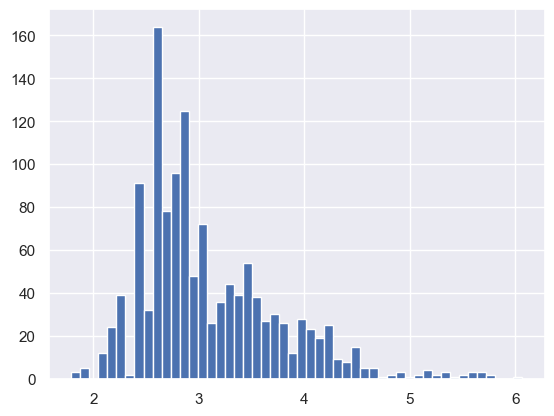

In [86]:
#price normalization
y = np.log1p(data['Price'])
np.log1p(data['Price']).hist(bins=50)


In [88]:
data.to_csv("wine_cleaned.csv", index=False)